In [83]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns


# 데이터 불러오기
merchant_df = pd.read_csv('../data/raw/big_data_set1_f.csv', encoding='cp949')
sale_df = pd.read_csv('../data/raw/big_data_set2_f.csv', encoding='cp949')
cust_df = pd.read_csv('../data/raw/big_data_set3_f.csv', encoding='cp949')
dddd = pd.read_csv('../data/raw/임대료추이.csv')




In [42]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


# 데이터 불러오기
merchant_df = pd.read_csv('../data/raw/big_data_set1_f.csv', encoding='cp949')
sale_df = pd.read_csv('../data/raw/big_data_set2_f.csv', encoding='cp949')
cust_df = pd.read_csv('../data/raw/big_data_set3_f.csv', encoding='cp949')


## 컬럼명 변경
def rename_column(merchant_df, sale_df, cust_df):
    # merchant_df 컬럼명 변경
    merchant_df.columns = ['가맹점구분번호', '가맹점주소', '가맹점명', '브랜드구분코드', '가맹점지역', '업종', '상권', '개설일', '폐업일']

    # sale_df 컬럼명 변경
    sale_df.columns = ['가맹점구분번호', '기준년월', '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간', '객단가 구간', '취소율 구간', '배달매출금액 비율', 
                   '동일 업종 매출금액 비율', '동일 업종 매출건수 비율', '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중']
    # cust_df 컬럼명 변경
    cust_df.columns = ['가맹점구분번호', '기준년월', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중', 
                   '재방문 고객 비중', '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율']
    
    return merchant_df, sale_df, cust_df


## 구간 데이터 전처리
def preprocess_sale(sale_df):
    # 복사본 생성
    sale_df_prc = sale_df.copy()

    # 구간 데이터 앞에 숫자만 빼오기
    sale_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'] = sale_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'].apply(lambda x: x.str.split('_', expand=True)[0])

    # 결측치 최빈값으로 대체 후 구간 데이터들의 자료형 int형으로 변환
    # 가정: 결측값의 경우 취소율이 적다고 판단!!
    band_cols = sale_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'].columns
    sale_df_prc[band_cols] = sale_df_prc[band_cols].fillna(1).astype(int)

    ## 비율 데이터 전처리
    # 배달매출금액 비율의 -999999.9는 배달매출 미존재 의미 => 0으로 대체 가능 (배달매출금액 비율이 처음부터 0인 데이터도 있긴 함)
    sale_df_prc['배달매출금액 비율'] = sale_df_prc['배달매출금액 비율'].map(lambda x: 0 if x < 0 else x)

    # 동일 상권 내 해지 가맹점 비중의 -999999.9는 상권 미존재 의미 => 100으로 할 수 도 있겠으나 일단 0으로 대체
    sale_df_prc['동일 상권 내 해지 가맹점 비중'] = sale_df_prc['동일 상권 내 해지 가맹점 비중'].map(lambda x: 0 if x < 0 else x)

    # 가맹점별 매출정보 평균계산
    sale_df_prc = sale_df_prc.groupby(['가맹점구분번호', '기준년월']).mean().reset_index()


    # sale_df_prc 데이터와 merchant_df 결합한 데이터 merged_df에 저장
    return sale_df_prc


## 고객 데이터 전처리
def preprocess_cust(cust_df):
    # 복사본 생성
    cust_df_prc = cust_df.copy()
    # 결측치는 0으로 대체
    cust_cols = cust_df_prc.iloc[:, 2:].columns
    cust_df_prc[cust_cols] = cust_df_prc[cust_cols].clip(lower=0)

     #  100 - (첫방문 비율 + 재방문 비율) 나타내는 컬럼 추가
    cust_df_prc['신규 재방문 외 고객'] = 100 - (cust_df_prc['재방문 고객 비중'] + cust_df_prc['신규 고객 비중'])

    # visit 관련 컬럼끼리 보기 편하게 컬럼 순서 조정
    cust_df_prc = cust_df_prc[['가맹점구분번호', '기준년월', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중', 
                               '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중', 
                               '재방문 고객 비중', '신규 고객 비중', '신규 재방문 외 고객', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율']]
    
    #  가맹점별 고객정보 평균계산
    cust_df_prc = cust_df_prc.groupby(['가맹점구분번호', '기준년월']).mean().reset_index()


    # cust_df_prc 데이터 merged_df에 추가
    return cust_df_prc

## 가맹점 데이터 전처리
def preprocess_merchant(merchant_df):
    # 복사본 생성
    merchant_df_prc = merchant_df.copy()
    
    ## 업종 그룹화 
    meat = ['한식-육류/고기',  '꼬치구이']
    cafe = ['카페',  '주스',  '차',  '테마카페',  '커피전문점', '테이크아웃커피',  '구내식당/푸드코트']
    k_food = ['백반/가정식',  '기사식당', '한식-두부요리', '한식-단품요리일반',  '한정식',    '한식-죽',  '한식-국수/만두',  '한식-국밥/설렁탕',  '한식-찌개/전골',  '한식-냉면',  '한식뷔페',  '한식-감자탕',   '한식-해물/생선']
    w_food = ['양식',  '스테이크', '치킨',  '햄버거',  '피자']
    j_food = ['일식당',  '일식-우동/소바/라면',  '일식-초밥/롤',  '일식-덮밥/돈가스',  '일식-샤브샤브',  '일식-참치회']
    c_food = ['중식당',  '중식-딤섬/중식만두',  '중식-훠궈/마라탕']
    drink = ['호프/맥주',  '요리주점',  '민속주점',  '포장마차',  '이자카야',  '와인바', '주류',  '와인샵']
    product= ['농산물',  '청과물',  '수산물',  '건어물',  '축산물']
    enter = ['일반 유흥주점',  '룸살롱/단란주점']
    convenience = ['샌드위치/토스트',  '도시락', '분식']
    world_food = ['동남아/인도음식',  '기타세계요리']
    dessert = ['도너츠',  '탕후루',  '와플/크로플',  '마카롱',  '아이스크림/빙수',  '떡/한과',  '떡/한과 제조',  '베이커리']
    others = ['식품 제조',  '반찬',  '미곡상',  '유제품',  '인삼제품', '건강식품', '건강원', '담배',  '식료품']

    # replace 진행
    groups_to_replace = [(meat, 'meat'), (cafe, 'cafe'), (k_food, 'k_food'), (w_food, 'w_food'), (j_food, 'j_food'),
                         (c_food, 'c_food'), (drink, 'drink'), (product, 'product'), (enter, 'enter'), (convenience, 'convenience'),
                         (world_food, 'world_food'), (dessert, 'dessert'), (others, 'others')]
    
    replacement = {}
    for ind, cat in groups_to_replace:
        for i in ind:
            replacement[i] = cat

    merchant_df_prc['업종'].replace(replacement, inplace=True)

    ## 상권 그룹화
    # 상권 데이터 1개만 존재하는 경우 주변 상권과 통합 (장한평자동차와 답십리는 모두 구석진 곳인데 가까우므로 결합)
    areas_to_replace = {'화양시장': '성수', '자양': '성수', '서면역': '성수', '미아사거리': '성수',
                        '방배역': '뚝섬', '건대입구': '뚝섬', '풍산지구': '뚝섬', '오남': '한양대',
                        '동대문역사문화공원역': '금남시장',  '압구정로데오': '금남시장',  '장한평자동차': '답십리'}
    
    merchant_df_prc['상권'].replace(areas_to_replace, inplace=True)

    # 상권 결측치는 Unknown으로 대체
    merchant_df_prc['상권'].fillna('Unknown', inplace=True)
    
    ## 상권 결측치 대체
    merchant_df_prc.loc[merchant_df_prc['상권']=='Unknown', '가맹점주소'].str.split(expand=True)[2].value_counts()
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로 410')), '상권'] = '왕십리'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로31')), '상권'] = '왕십리'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('마장로 137')), '상권'] = '왕십리'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('무학로 33')), '상권'] = '왕십리'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('마장로35길')), '상권'] = '마장동'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('마장로37길')), '상권'] = '마장동'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('마장')), '상권'] = '마장동'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('금호로')), '상권'] = '신금호'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('행당로')), '상권'] = '행당'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로 58')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점구분번호'].str.contains('1F0AADBBB8')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로 16')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로14')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('동일로')), '상권'] = '성수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('광나루로')), '상권'] = '성수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('아차산로')), '상권'] = '성수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('매봉길')), '상권'] = '옥수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('옥수2동')), '상권'] = '옥수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('연무장')), '상권'] = '성수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('성덕정')), '상권'] = '성수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('서울숲2길')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('무학봉길')), '상권'] = '왕십리'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('송정')), '상권'] = '성수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('성수')), '상권'] = '성수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('둘레1길')), '상권'] = '성수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('독서당로')), '상권'] = '행당'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로 50')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리로 6')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('왕십리')), '상권'] = '왕십리'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('무학')), '상권'] = '왕십리'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('난계로')), '상권'] = '왕십리'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('홍익동')), '상권'] = '왕십리'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('살곶이')), '상권'] = '한양대'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('마조로')), '상권'] = '한양대'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('사근동')), '상권'] = '한양대'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('뚝섬로 3')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('뚝섬로1가')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('뚝섬로1길')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('서울숲길')), '상권'] = '뚝섬'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('뚝섬로')), '상권'] = '성수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('선릉')), '상권'] = '성수'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('고산자로')), '상권'] = '행당'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('응봉동')), '상권'] = '행당'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('장터')), '상권'] = '금남시장'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('동호')), '상권'] = '금남시장'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('청계천')), '상권'] = '마장동'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('금호')), '상권'] = '신금호'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('자동차시장길')), '상권'] = '답십리'
    merchant_df_prc.loc[(merchant_df_prc['상권']=='Unknown') & (merchant_df_prc['가맹점주소'].str.contains('용답')), '상권'] = '답십리'

    return merchant_df_prc

## 최종 전처리
def preprocess_merged(merged_df):
    # 복사본 생성
    final_df = merged_df.copy()

    # is_closed 컬럼 생성
    final_df['is_closed'] = final_df['폐업일'].notna().astype(int)

    # 불필요 컬럼 제거
    final_df.drop(['가맹점주소', '가맹점명', '브랜드구분코드', '가맹점지역', '개설일',], axis=1, inplace=True)

    # 상관계수 절댓값이 0.7 이상인 컬럼들이 있으면 둘 중 하나 제거
    final_df.drop(['매출금액 구간', '유니크 고객 수 구간', '동일 업종 매출건수 비율', '동일 업종 내 매출 순위 비율'], axis=1, inplace=True)

    # One-Hot Encoding 진행
    final_df = pd.get_dummies(final_df, drop_first=True, dtype=int)

    return final_df

## 통합
def apply_all(merchant_df, sale_df, cust_df):
    # 컬럼 이름 변경
    merchant_df, sale_df, cust_df = rename_column(merchant_df, sale_df, cust_df)
    
    # merchant_df 전처리
    merchant_df = preprocess_merchant(merchant_df)

    # sale_df 전처리
    sale_df_prc = preprocess_sale(sale_df)

    # cust_df 전처리
    cust_df_prc = preprocess_cust(cust_df)

    # merchant, sale, cust 통합
    merged_df = pd.merge(merchant_df, sale_df_prc, on='가맹점구분번호', how='inner')  # 첫 번째 병합
    merged_df = pd.merge(merged_df, cust_df_prc, on=['가맹점구분번호', '기준년월'], how='inner')
    
    # merged_df 전처리
    final_df = preprocess_merged(merged_df)
    
    return final_df,merged_df




In [43]:
final_df,merged_df = apply_all(merchant_df, sale_df, cust_df)


In [44]:
# merchant_df.head(50)

In [45]:
# sale_df.head(50)

In [46]:
# cust_df.head(50)

In [56]:
# final_df.head(50)

,폐업일,기준년월,가맹점 운영개월수 구간,매출건수 구간,객단가 구간,취소율 구간,배달매출금액 비율,동일 업종 매출금액 비율,동일 상권 내 매출 순위 비율,동일 업종 내 해지 가맹점 비중,...,업종_world_food,상권_답십리,상권_뚝섬,상권_마장동,상권_성수,상권_신금호,상권_옥수,상권_왕십리,상권_한양대,상권_행당
0,NaN,202301,2.0,4.0,2.0,1.0,0.0,110.6,20.8,10.0,...,0,0,0,1,0,0,0,0,0,0
1,NaN,202302,2.0,4.0,1.0,1.0,0.0,93.6,21.7,10.5,...,0,0,0,1,0,0,0,0,0,0
2,NaN,202303,2.0,4.0,2.0,6.0,0.0,106.5,21.4,10.9,...,0,0,0,1,0,0,0,0,0,0
3,NaN,202304,2.0,4.0,2.0,6.0,0.0,74.6,21.3,11.3,...,0,0,0,1,0,0,0,0,0,0
4,NaN,202305,2.0,4.0,1.0,6.0,0.0,134.0,21.3,11.6,...,0,0,0,1,0,0,0,0,0,0
5,NaN,202306,2.0,4.0,1.0,1.0,0.0,92.2,21.7,11.7,...,0,0,0,1,0,0,0,0,0,0
6,NaN,202307,2.0,4.0,2.0,1.0,0.0,81.7,20.8,11.8,...,0,0,0,1,0,0,0,0,0,0
7,NaN,202308,2.0,4.0,2.0,1.0,0.0,85.6,20.6,12.0,...,0,0,0,1,0,0,0,0,0,0
8,NaN,202309,2.0,4.0,1.0,6.0,0.0,199.4,20.7,12.0,...,0,0,0,1,0,0,0,0,0,0
9,NaN,202310,2.0,4.0,2.0,1.0,0.0,69.6,21.5,12.2,...,0,0,0,1,0,0,0,0,0,0


In [48]:
final_df['기준년월']

0        202301
1        202302
2        202303
3        202304
4        202305
          ...  
86585    202408
86586    202409
86587    202410
86588    202411
86589    202412
Name: 기준년월, Length: 86590, dtype: int64

In [49]:
# 특정 컬럼 값 확인
print(final_df['기준년월'].head())

# 데이터 프레임 전체 구조 확인
final_df.info()


0    202301
1    202302
2    202303
3    202304
4    202305
Name: 기준년월, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Columns: 4233 entries, 폐업일 to 상권_행당
dtypes: float64(26), int64(4207)
memory usage: 2.7 GB


In [60]:
target_col = '객단가 구간'   
months_back = 12             
months_forward = 0          

def plot_closure_trend(df):
    plt.rcParams['font.family'] = 'Malgun Gothic'  
    plt.rcParams['axes.unicode_minus'] = False 
    
    global target_col, months_back, months_forward

    df = df.copy()
    df['기준년월'] = pd.to_datetime(df['기준년월'].astype(str), format='%Y%m')

    closed_df = df[df['is_closed'] == 1]

    closure_month = closed_df.groupby('가맹점구분번호')['기준년월'].max().reset_index()
    closure_month.columns = ['가맹점구분번호', '폐업월']

    df = pd.merge(df, closure_month, on='가맹점구분번호', how='left')

    df_closed = df[df['폐업월'].notna()].copy()

    df_closed['month_offset'] = ((df_closed['폐업월'].dt.year - df_closed['기준년월'].dt.year) * 12 +
                                 (df_closed['폐업월'].dt.month - df_closed['기준년월'].dt.month)) * -1

    df_window = df_closed[(df_closed['month_offset'] >= -months_back) &
                          (df_closed['month_offset'] <= months_forward)]


    trend = df_window.groupby('month_offset')[target_col].mean().reset_index()


    plt.figure(figsize=(8, 5))
    plt.plot(trend['month_offset'], trend[target_col], marker='o', color='blue')
    plt.axvline(0, color='red', linestyle='--', label='폐업월')
    plt.title(f"[{target_col}] 폐업 기준 {months_back}개월 전~{months_forward}개월 후 추이")
    plt.xlabel('폐업월로부터 경과 개월 (음수=이전)')
    plt.ylabel(target_col)
    plt.grid(True)
    plt.legend()
    plt.show()


In [66]:
num_df = merged_df

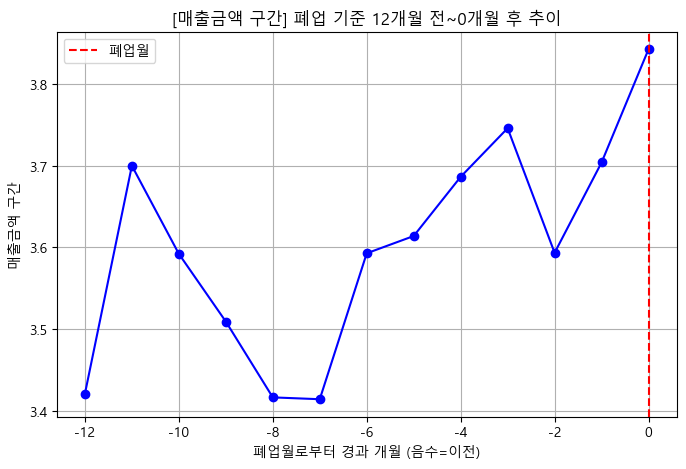

In [67]:
target_col = '매출금액 구간'   
months_back = 12             
months_forward = 0 
merged_df['is_closed'] = merged_df['폐업일'].notna().astype(int)

plot_closure_trend(num_df)

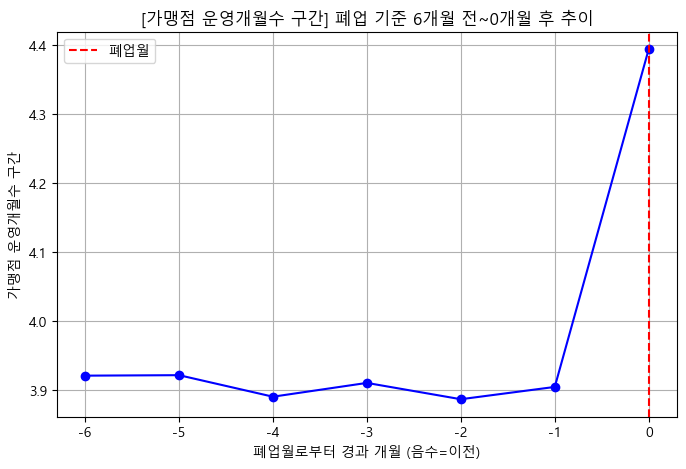

In [68]:
target_col = '가맹점 운영개월수 구간'   
months_back = 6             
months_forward = 0 
merged_df['is_closed'] = merged_df['폐업일'].notna().astype(int)

plot_closure_trend(num_df)

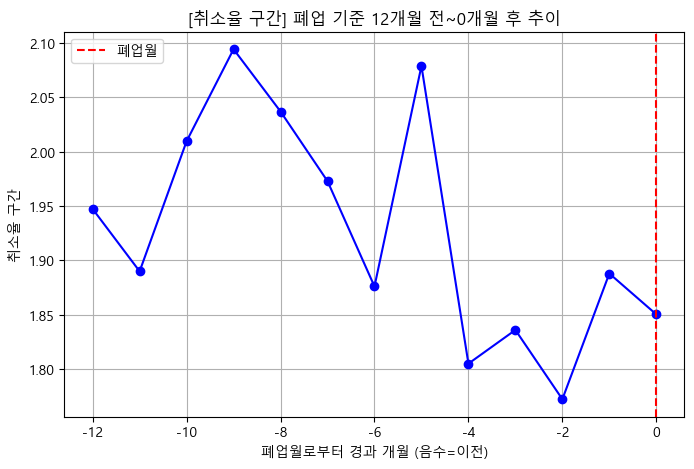

In [81]:
target_col = '취소율 구간'   
months_back = 12             
months_forward = 0 


plot_closure_trend(num_df)

In [70]:
num_df.columns

Index(['가맹점구분번호', '가맹점주소', '가맹점명', '브랜드구분코드', '가맹점지역', '업종', '상권', '개설일',
       '폐업일', '기준년월', '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간',
       '객단가 구간', '취소율 구간', '배달매출금액 비율', '동일 업종 매출금액 비율', '동일 업종 매출건수 비율',
       '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중',
       '동일 상권 내 해지 가맹점 비중', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중',
       '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중',
       '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중', '재방문 고객 비중',
       '신규 고객 비중', '신규 재방문 외 고객', '거주 이용 고객 비율', '직장 이용 고객 비율',
       '유동인구 이용 고객 비율', 'is_closed'],
      dtype='object')

In [ ]:
num_df.drop['가맹점주소','브랜드구분코드'

In [76]:
def plot_closure_bar(df):

    global cat_col, num_col, months_back

    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    df = df.copy()
    df['기준년월'] = pd.to_datetime(df['기준년월'].astype(str), format='%Y%m')

    if 'is_closed' not in df.columns and '폐업일' in df.columns:
        df['is_closed'] = df['폐업일'].notna().astype(int)

    closed_df = df[df['is_closed'] == 1]
    closure_month = closed_df.groupby('가맹점구분번호')['기준년월'].max().reset_index()
    closure_month.columns = ['가맹점구분번호', '폐업월']

    df = pd.merge(df, closure_month, on='가맹점구분번호', how='left')
    df['개월차'] = (df['기준년월'].dt.year - df['폐업월'].dt.year) * 12 + \
              (df['기준년월'].dt.month - df['폐업월'].dt.month)

    df_plot = df[(df['개월차'] >= -months_back) & (df['개월차'] <= 0)]

    bar_df = df_plot.groupby(cat_col)[num_col].mean().sort_values(ascending=False).reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=bar_df, x=num_col, y=cat_col, palette='coolwarm', orient='h')

    plt.title(f"[{cat_col}]별 {num_col} 평균 (폐업 전 {months_back}개월)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(f"{num_col} 평균", fontsize=12)
    plt.ylabel(cat_col, fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


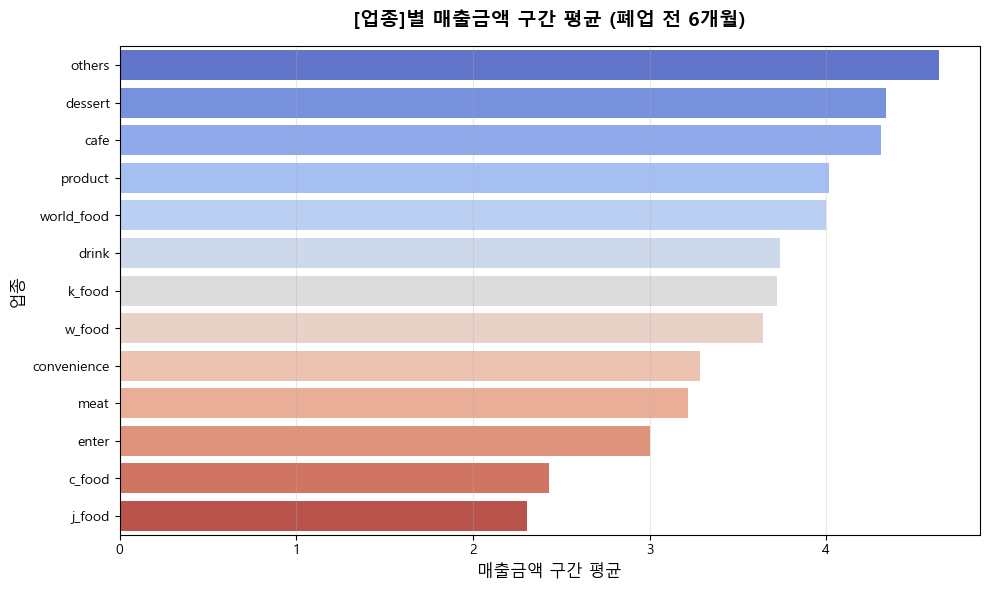

In [77]:
cat_col='업종'
num_col='매출금액 구간'
months_back=6
plot_closure_bar(num_df)